# CoastWatch Ocean Heat Content → VirtualiZarr → Icechunk on Source Cooperative

The pre-2024 data is NetCDF while the later data is HDF5. Encoding is different for the later data 

```
https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na/2020
```

The large array bytes remain in the CoastWatch HTTPS source; Icechunk
stores only metadata and byte-range references.

In [1]:
# Uncomment if needed
!pip install -q "icechunk>=2.1" "virtualizarr>=2.4" xarray obspec_utils obstore h5netcdf requests matplotlib

In [8]:
import sys
# icechunk_utils.py lives at the repo root (one level up) in the git repo, or
# alongside this notebook when downloaded from Source Cooperative. Jupyter puts
# the notebook's directory on sys.path, so a co-located copy is importable; the
# '..' entry below covers the nested git-repo layout.
sys.path.insert(0, '..')

import time
from pathlib import Path

import requests
import xarray as xr
import icechunk
from obstore.store import HTTPStore
from obspec_utils.registry import ObjectStoreRegistry
from virtualizarr import open_virtual_dataset
from virtualizarr.parsers import NetCDF3Parser

from icechunk_utils import open_source_icechunk_repo, wait_for_fresh_repo

## Source URLs

First 5 daily files from the 2020 North Atlantic OHC archive.
Files begin at day-of-year 121; adjust `doys` if earlier days are added.

In [6]:
year = 2020
base = f"https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na/{year}"

doys = [121, 122, 123, 124, 125]
urls = [f"{base}/ohc_naQG3_{year}_{doy}.nc" for doy in doys]

urls

['https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na/2020/ohc_naQG3_2020_121.nc',
 'https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na/2020/ohc_naQG3_2020_122.nc',
 'https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na/2020/ohc_naQG3_2020_123.nc',
 'https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na/2020/ohc_naQG3_2020_124.nc',
 'https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na/2020/ohc_naQG3_2020_125.nc']

## 1. Confirm HTTP byte-range access

CoastWatch rejects the default `python-requests` User-Agent.
A browser-like UA is required for both the byte-range check and VirtualiZarr.

In [9]:
BROWSER_UA = (
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/150.0.0.0 Safari/537.36"
)

r = requests.get(
    urls[0],
    headers={"User-Agent": BROWSER_UA, "Range": "bytes=0-99"},
)

print("status:", r.status_code)
print("content-range:", r.headers.get("Content-Range"))
print("accept-ranges:", r.headers.get("Accept-Ranges"))
print("bytes returned:", len(r.content))

assert r.status_code == 206, "Server did not honor the byte-range request"
assert len(r.content) == 100

status: 206
content-range: bytes 0-99/2811084
accept-ranges: bytes
bytes returned: 100


In [5]:
boundary_urls = [
    "https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na14/2025/ohc_na14QG3_2025_084.nc",
    "https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na14/2025/ohc_na14QG3_2025_085.nc",
]

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/core/dtype/npy/bytes.py:386: UnstableSpecificationWarning: The data type (NullTerminatedBytes(length=1)) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)



 https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na14/2025/ohc_na14QG3_2025_084.nc
format: NetCDF-3 classic
chunks: (1, 241, 401)
codecs: (BytesCodec(endian='big'),)

 https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na14/2025/ohc_na14QG3_2025_085.nc
format: HDF5
chunks: (1, 241, 401)
codecs: (BytesCodec(endian='little'),)


## 2. Configure the HTTPS object store and Icechunk virtual chunk container

In [21]:
http_store = HTTPStore(
    base,
    client_options={"user_agent": BROWSER_UA},
)

registry = ObjectStoreRegistry({base: http_store})

# NetCDF3Parser uses kerchunk/fsspec internally, so the User-Agent must be
# passed via reader_options — the registry UA is not used for the metadata read.
parser = NetCDF3Parser(reader_options={
    "storage_options": {
        "client_kwargs": {"headers": {"User-Agent": BROWSER_UA}}
    }
})

http_prefix = base + "/"

config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=http_prefix,
        store=icechunk.http_store(),
    )
)

credentials = icechunk.containers_credentials({
    http_prefix: icechunk.credentials.HttpAccess
})

## 3. Open or create the Icechunk repository on Source Cooperative

Writing to `fish-pace/coastwatch/ocean-heat`. Credentials are managed
by `icechunk_utils.open_source_icechunk_repo` via the source-coop CLI.

In [11]:
SC_BUCKET = "fish-pace"
SC_PREFIX = "coastwatch/ocean-heat"
GROUP = "test"

repo, storage, creds, time_left = open_source_icechunk_repo(
    bucket=SC_BUCKET,
    prefix=SC_PREFIX,
    config=config,
)

session = repo.writable_session("main")

Created new Icechunk repo
Time remaining on token: 9:35:30.673125


In [24]:
urls[0]

'https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na/2020/ohc_naQG3_2020_121.nc'

In [33]:
base = "https://coastwatch.noaa.gov"

http_store = HTTPStore(
    base,
    client_options={"user_agent": BROWSER_UA},
)

registry = ObjectStoreRegistry({
    base: http_store
})

url="https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na/2024/ohc_naQG3_2024_018.nc"
url="https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na/2024/ohc_naQG3_2024_001.nc"
url="https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na14/2024/ohc_na14QG3_2024_015.nc"
vds = open_virtual_dataset(
    url=url,
    parser=parser,
    registry=registry,
    loadable_variables=["time", "latitude", "longitude"],
    decode_times=True,
).drop_vars(["crs"], errors="ignore")
vds

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/core/dtype/npy/bytes.py:386: UnstableSpecificationWarning: The data type (NullTerminatedBytes(length=1)) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


<xarray.Dataset> Size: 3MB
Dimensions:              (latitude: 241, longitude: 401, time: 1,
                          quality_character: 1)
Coordinates:
  * latitude             (latitude) float32 964B 0.0 0.25 0.5 ... 59.75 60.0
  * longitude            (longitude) float32 2kB -100.0 -99.75 ... -0.25 0.0
  * time                 (time) datetime64[ns] 8B 2024-01-15T23:51:28
Dimensions without coordinates: quality_character
Data variables:
    landmask             (time, latitude, longitude) int8 97kB ManifestArray<...
    sst                  (time, latitude, longitude) float32 387kB ManifestAr...
    ssha                 (time, latitude, longitude) float32 387kB ManifestAr...
    sshaE                (time, latitude, longitude) float32 387kB ManifestAr...
    iso20C               (time, latitude, longitude) float32 387kB ManifestAr...
    iso26C               (time, latitude, longitude) float32 387kB ManifestAr...
    omld                 (time, latitude, longitude) float32 387kB ManifestAr...
    ohc                  (time, latitude, longitude) float32 387kB ManifestAr...
    quality_information  (quality_character) |S1 1B ManifestArray<shape=(1,),...
    quality_flag         (time, latitude, longitude) int32 387kB ManifestArra...
Attributes: (12/63)
    Conventions:                             CF-1.6, ACDD-1.3
    Metadata_Conventions:                    Unidata Dataset Discovery v1.0
    title:                                   OHC_NAQG3
    source_data:                             SMARTS Climatology+Altimeter SHA...
    sourceUrl:                               http://www.ospo.noaa.gov/Product...
    spatial_resolution:                      0.25 degree
    ...                                      ...
    bounding_box_iso26C_average:             106.88173828125
    bounding_box_iso26C_variance:            17.538669963395225
    bounding_box_iso26C_standard_deviation:  4.187919526852829
    bounding_box_ohc_average:                77.9669677734375
    bounding_box_ohc_variance:               7.5352148315585215
    bounding_box_ohc_standard_deviation:     2.7450345774795846

In [27]:
from obstore.store import HTTPStore
from obspec_utils.registry import ObjectStoreRegistry
from virtualizarr import open_virtual_dataset
from virtualizarr.parsers import NetCDF3Parser

base = "https://coastwatch.noaa.gov"

BROWSER_UA = (
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/150.0.0.0 Safari/537.36"
)

http_store = HTTPStore(
    base,
    client_options={"user_agent": BROWSER_UA},
)

registry = ObjectStoreRegistry({
    base: http_store
})

parser = NetCDF3Parser(
    reader_options={
        "storage_options": {
            "client_kwargs": {
                "headers": {
                    "User-Agent": BROWSER_UA
                }
            }
        }
    }
)

url = (
    "https://coastwatch.noaa.gov/pub/socd2/coastwatch/"
    "ocean_heat/na/2024/ohc_naQG3_2024_001.nc"
)

vds = open_virtual_dataset(
    url=url,
    parser=parser,
    registry=registry,
    loadable_variables=["time", "latitude", "longitude"],
    decode_times=True,
).drop_vars(["crs"], errors="ignore")

vds

<xarray.Dataset> Size: 3MB
Dimensions:    (latitude: 241, longitude: 401, time: 1)
Coordinates:
  * latitude   (latitude) float32 964B 0.0 0.25 0.5 0.75 ... 59.5 59.75 60.0
  * longitude  (longitude) float32 2kB -100.0 -99.75 -99.5 ... -0.5 -0.25 0.0
  * time       (time) datetime64[ns] 8B 2024-01-01
Data variables:
    landmask   (time, latitude, longitude) int8 97kB ManifestArray<shape=(1, ...
    sst        (time, latitude, longitude) float32 387kB ManifestArray<shape=...
    ssha       (time, latitude, longitude) float32 387kB ManifestArray<shape=...
    sshaE      (time, latitude, longitude) float32 387kB ManifestArray<shape=...
    iso20C     (time, latitude, longitude) float32 387kB ManifestArray<shape=...
    iso26C     (time, latitude, longitude) float32 387kB ManifestArray<shape=...
    omld       (time, latitude, longitude) float32 387kB ManifestArray<shape=...
    ohc        (time, latitude, longitude) float32 387kB ManifestArray<shape=...
Attributes: (12/26)
    Conventions:                CF-1.6
    Metadata_Conventions:       Unidata Dataset Discovery v1.0
    title:                      Ocean Heat Content Product Suite
    source_data:                SMARTS Climatology+Altimeter SHA+GeoPolar Ble...
    sourceUrl:                  http://www.ospo.noaa.gov/Products/ocean/ocean...
    spatial_resolution:         0.25 degree
    ...                         ...
    keywords_vocabulary:        GCMD Science Keywords
    data_source:                USDOC/NOAA/NESDIS/OSPO
    origin:                     USDOC/NOAA/NESDIS/OSPO
    comment:                    NOAA OSPO Ocean Heat Content\nhttp://www.ospo...
    map_projection:             Geographic
    summary:                    The Satellite Ocean Heat Content (OHC) Suite ...

## 4. Virtualize and append the 5 daily files

The first file creates the group hierarchy; subsequent files append along `time`.
Each commit is a separate snapshot so work is not lost if the loop is interrupted.

In [12]:
for i, url in enumerate(urls):
    t0 = time.perf_counter()
    print(f"[{i+1}/{len(urls)}] {Path(url).name}")

    vds = open_virtual_dataset(
        url=url,
        parser=parser,
        registry=registry,
        loadable_variables=["time", "latitude", "longitude"],
        decode_times=True,
    ).drop_vars(["crs"], errors="ignore")

    if i == 0:
        vds.vz.to_icechunk(session.store, group=GROUP)
    else:
        vds.vz.to_icechunk(session.store, group=GROUP, append_dim="time")

    snapshot_id = session.commit(f"Add {Path(url).name}")
    print(f"  committed {snapshot_id} in {time.perf_counter() - t0:.2f}s")

    # Refresh session after each commit
    session = repo.writable_session("main")

print("Done.")

[1/5] ohc_naQG3_2020_121.nc
  committed 26N373792P5YD45Z1GG0 in 3.38s
[2/5] ohc_naQG3_2020_122.nc
  committed 3V06RSJ4SKQYDDMMVM6G in 2.48s
[3/5] ohc_naQG3_2020_123.nc
  committed 40033YPR33M2GFBCQ7PG in 2.33s
[4/5] ohc_naQG3_2020_124.nc
  committed 1R9D17844HBSW0V27WF0 in 2.46s
[5/5] ohc_naQG3_2020_125.nc
  committed FAEMY2210SX1GBMPC80G in 4.10s
Done.


## 5. Reopen and verify

Reopening from Source Cooperative confirms the metadata round-trips correctly.
Reading a science variable fetches the original bytes from CoastWatch over HTTPS.

In [13]:
repo2 = icechunk.Repository.open(
    storage,
    config=config,
    authorize_virtual_chunk_access=credentials,
)

ds = xr.open_zarr(
    repo2.readonly_session("main").store,
    consolidated=False,
    group=GROUP,
)

ds

<xarray.Dataset> Size: 14MB
Dimensions:    (time: 5, latitude: 241, longitude: 401)
Coordinates:
  * time       (time) datetime64[ns] 40B 2020-04-30 2020-05-01 ... 2020-05-04
  * latitude   (latitude) float32 964B 0.0 0.25 0.5 0.75 ... 59.5 59.75 60.0
  * longitude  (longitude) float32 2kB -100.0 -99.75 -99.5 ... -0.5 -0.25 0.0
Data variables:
    ohc        (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 241, 401), meta=np.ndarray>
    iso26C     (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 241, 401), meta=np.ndarray>
    sst        (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 241, 401), meta=np.ndarray>
    iso20C     (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 241, 401), meta=np.ndarray>
    omld       (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 241, 401), meta=np.ndarray>
    landmask   (time, latitude, longitude) int8 483kB dask.array<chunksize=(1, 241, 401), meta=np.ndarray>
    ssha       (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 241, 401), meta=np.ndarray>
    sshaE      (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 241, 401), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                CF-1.6
    Metadata_Conventions:       Unidata Dataset Discovery v1.0
    title:                      Ocean Heat Content Product Suite
    source_data:                SMARTS Climatology+Altimeter SHA+GeoPolar Ble...
    sourceUrl:                  http://www.ospo.noaa.gov/Products/ocean/ocean...
    spatial_resolution:         0.25 degree
    ...                         ...
    keywords_vocabulary:        GCMD Science Keywords
    data_source:                USDOC/NOAA/NESDIS/OSPO
    origin:                     USDOC/NOAA/NESDIS/OSPO
    comment:                    NOAA OSPO Ocean Heat Content\nhttp://www.ospo...
    map_projection:             Geographic
    summary:                    The Satellite Ocean Heat Content (OHC) Suite ...

In [16]:
print(ds["ohc"].isel(time=0).values)

[[-999.       -999.       -999.       ...   39.70435    35.54963
    34.03868 ]
 [-999.       -999.       -999.       ...   39.919567   36.87668
    35.71043 ]
 [-999.       -999.       -999.       ...   43.398468   37.98776
    36.573227]
 ...
 [-999.       -999.       -999.       ...    0.          0.
     0.      ]
 [-999.       -999.       -999.       ...    0.          0.
     0.      ]
 [-999.       -999.       -999.       ...    0.          0.
     0.      ]]


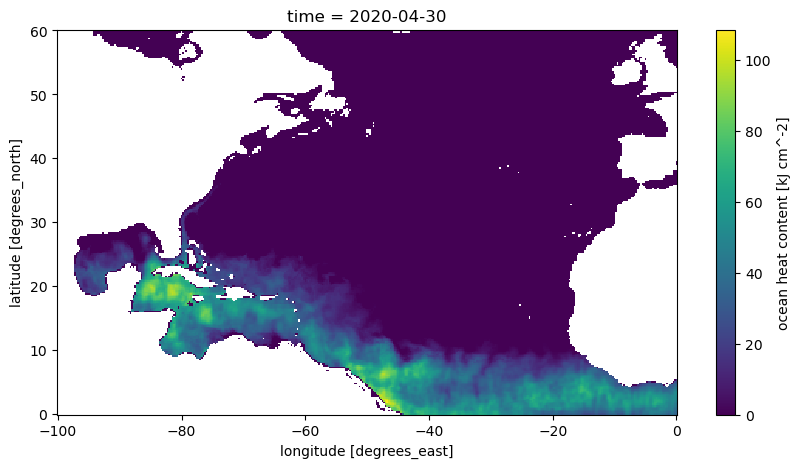

In [17]:
ohc = ds["ohc"].isel(time=0).where(ds["ohc"].isel(time=0) != -999)

ohc.plot(
    x="longitude",
    y="latitude",
    figsize=(10, 5),
)

## Troubleshooting

In [18]:
# List everything
import boto3
import json
_DEFAULT_CREDS_CACHE = "/home/jovyan/.cache/source-coop/credentials/_default.json"

with open(_DEFAULT_CREDS_CACHE) as f:
    creds = json.load(f)

s3 = boto3.client(
    "s3",
    endpoint_url="https://data.source.coop",
    aws_access_key_id=creds["access_key_id"],
    aws_secret_access_key=creds["secret_access_key"],
    aws_session_token=creds["session_token"],
)

bucket = "fish-pace"
prefix = "coastwatch/"
DRY_RUN = True

paginator = s3.get_paginator("list_objects_v2")

keys = []

for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
    for obj in page.get("Contents", []):
        keys.append(obj["Key"])
        print(f'{obj["Size"]:>12,}  {obj["Key"]}')

print(f"\nFound {len(keys):,} objects under s3://{bucket}/{prefix}")

         964  coastwatch/ocean-heat/chunks/11CCCTN29WF0CMET13EG
       1,604  coastwatch/ocean-heat/chunks/1J98ED5HC8VJGH4SRHK0
         964  coastwatch/ocean-heat/chunks/CT8HED1XKMP16Z11SCK0
       1,604  coastwatch/ocean-heat/chunks/FV4BR9S7VE54MYNGSAF0
       1,604  coastwatch/ocean-heat/chunks/HDSYVB9BSFYBP9JZ3JA0
         964  coastwatch/ocean-heat/chunks/MRRZDHTZHV2G15X37VB0
         964  coastwatch/ocean-heat/chunks/QC4QG0VEBS926S15D7P0
         964  coastwatch/ocean-heat/chunks/QEGAR2SHZNHQGT9ZNWAG
       1,604  coastwatch/ocean-heat/chunks/VHPEV6BR9NEBCMT0DN6G
       1,604  coastwatch/ocean-heat/chunks/Y50KF3S2F18Q32MVZME0
         264  coastwatch/ocean-heat/manifests/1Q36315810G9HK85G5W0
         238  coastwatch/ocean-heat/manifests/1SJ9YX2GGM88BG95MCZG
         267  coastwatch/ocean-heat/manifests/4GJRZ86VSBSA42WT1PN0
         323  coastwatch/ocean-heat/manifests/4K5V4GGB0TZ0NRDM6340
         303  coastwatch/ocean-heat/manifests/4VBY5X05KFTAC12X1REG
         304  coastwatch/

In [23]:
%%script false --no-raise
# Delete everything
import json
import boto3

_DEFAULT_CREDS_CACHE = "/home/jovyan/.cache/source-coop/credentials/_default.json"

with open(_DEFAULT_CREDS_CACHE) as f:
    creds = json.load(f)

bucket = "fish-pace"
prefix = "coastwatch/"

s3 = boto3.client(
    "s3",
    endpoint_url="https://data.source.coop",
    aws_access_key_id=creds["access_key_id"],
    aws_secret_access_key=creds["secret_access_key"],
    aws_session_token=creds["session_token"],
)

def delete_s3_prefix(bucket, prefix):
    prefix = prefix.strip("/") + "/"

    paginator = s3.get_paginator("list_objects_v2")

    # Gather keys first so changing the listing while paginating
    # does not cause objects to be skipped.
    keys = []

    for page in paginator.paginate(
        Bucket=bucket,
        Prefix=prefix,
    ):
        keys.extend(
            obj["Key"]
            for obj in page.get("Contents", [])
        )

    print(f"Found {len(keys)} objects under s3://{bucket}/{prefix}")

    for i, key in enumerate(keys, start=1):
        s3.delete_object(
            Bucket=bucket,
            Key=key,
        )

        if i % 100 == 0 or i == len(keys):
            print(f"Deleted {i} of {len(keys)} objects")

    print(f"Deleted everything under s3://{bucket}/{prefix}")


delete_s3_prefix(bucket, prefix)

Found 83 objects under s3://fish-pace/coastwatch/
Deleted 83 of 83 objects
Deleted everything under s3://fish-pace/coastwatch/
